# DATA 720 Final Project Proposal + Analysis Notebook

**Project Title:** Does Artificial Turf Produce Higher Injury Rates Than Natural Grass in NFL Games?  
**Course:** DATA 720 – Programming Methods for Data Science  
**Student:** *William McDonald*  
**Dataset:** NFL Playing Surface Analytics (Kaggle)

## Overview

This notebook is designed as a combined **proposal + analysis notebook** for the DATA 720 final project. The central question is whether artificial turf surfaces are associated with higher injury rates than natural grass in NFL games. This question is relevant to sports analytics, athlete safety, and applied data science because it uses publicly available play-level and injury data to test a concrete, measurable hypothesis.

## Research Question

Do artificial turf surfaces produce higher injury rates than natural grass in NFL games?

## Hypothesis

Artificial turf will be associated with a higher injury rate than natural grass.

## Why this dataset works for the project

The NFL Playing Surface Analytics dataset is publicly available and robust enough for multiple analyses. It includes play-level context and injury records, which allows the project to:

- load and inspect real-world data with Python and Pandas
- merge multiple datasets
- clean and standardize categorical variables
- compute injury rates by surface type
- visualize results
- run a statistical significance test


## Planned Analysis

This project will:

1. Load the dataset from Kaggle using `kagglehub`
2. Identify the relevant CSV files for play-level data and injury data
3. Clean and standardize field surface labels into broad groups
4. Merge the play-level table with the injury table
5. Create an injury indicator
6. Compare injury rates for artificial turf versus natural grass
7. Visualize the results
8. Run a chi-square test to determine whether the difference is statistically significant

## Expected Deliverables

- a clean, reproducible notebook
- summary statistics and visualizations
- a clear answer to the research question
- a short interpretation suitable for a report or poster

## Setup Notes

This notebook assumes:

- you have a valid Kaggle API token available at `~/.kaggle/kaggle.json`
- you can install `kagglehub[pandas-datasets]` if needed
- you will run the notebook locally in JupyterLab

If needed, uncomment the install line in the next cell.
- the first code cell will install missing Python packages if needed

In [1]:
# Bootstraps required packages if they are missing.
import sys
import subprocess
import importlib

required_packages = [
    ("kagglehub", "kagglehub[pandas-datasets]"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("seaborn", "seaborn"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
]

for module_name, pip_name in required_packages:
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

import os
from pathlib import Path

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Environment ready.")

/home/will/anaconda3/envs/qailab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.


## Download and Inspect the Dataset

Instead of manually downloading files, this notebook uses `kagglehub` to download the dataset into KaggleHub's local cache. Then it discovers the CSV files automatically.

Dataset source: `sudhanshu727/nfl-playing-surface-analytics`

In [2]:
dataset_dir = kagglehub.dataset_download("sudhanshu727/nfl-playing-surface-analytics")
dataset_dir = Path(dataset_dir)

print("Dataset downloaded to:")
print(dataset_dir)

csv_files = sorted(dataset_dir.rglob("*.csv"))
print("\nCSV files discovered:")
for f in csv_files:
    print("-", f.name)

Dataset downloaded to:
/home/will/.cache/kagglehub/datasets/sudhanshu727/nfl-playing-surface-analytics/versions/1

CSV files discovered:
- InjuryRecord.csv
- PlayList.csv
- PlayerTrackData.csv


## Helper Functions

These helpers make the notebook easier to debug and more robust across minor variations in column names.

In [3]:
def find_file(dataset_dir: Path, preferred_names):
    """Find a file recursively by trying several possible names."""
    all_csvs = list(dataset_dir.rglob("*.csv"))
    lower_map = {p.name.lower(): p for p in all_csvs}
    for name in preferred_names:
        p = lower_map.get(name.lower())
        if p is not None:
            return p
    raise FileNotFoundError(
        f"Could not find any of these files: {preferred_names}. "
        f"Available CSVs: {[p.name for p in all_csvs]}"
    )

def find_col(df, candidates):
    """Return the first matching column from a list of candidates, ignoring case/spacing."""
    normalized = {
        c.lower().replace(" ", "").replace("_", ""): c
        for c in df.columns
    }
    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("_", "")
        if key in normalized:
            return normalized[key]
    raise KeyError(f"None of these columns were found: {candidates}. Available columns: {list(df.columns)}")

def standardize_surface(value):
    """Map raw field surface text into broad groups."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()

    artificial_terms = [
        "artificial", "synthetic", "turf", "fieldturf", "astroturf", "matrix", "s5", "dd grassmaster"
    ]
    natural_terms = [
        "natural", "grass", "bermuda", "kentucky bluegrass", "bluegrass", "rye", "hybrid grass"
    ]

    # Important: check natural first for labels like "Natural Grass"
    if any(term in s for term in natural_terms):
        return "Natural Grass"
    if any(term in s for term in artificial_terms):
        return "Artificial Turf"
    return "Other / Unknown"

## Load the Core Tables

For this project, the most important files are the play-level table and the injury table. The large player-tracking file is not necessary for answering the core surface question, so it is intentionally skipped.

In [17]:
play_file = find_file(dataset_dir, ["PlayList.csv", "playlist.csv"])
injury_file = find_file(dataset_dir, ["InjuryRecord.csv", "injuryrecord.csv"])

plays = pd.read_csv(play_file)
injuries = pd.read_csv(injury_file)

print("Play file:", play_file.name, plays.shape)
print("Injury file:", injury_file.name, injuries.shape)

Play file: PlayList.csv (267005, 14)
Injury file: InjuryRecord.csv (105, 9)


In [18]:
display(plays.head())
display(injuries.head())

,PlayerKey,GameID,PlayKey,RosterPosition,PlayerDay,PlayerGame,StadiumType,FieldType,Temperature,Weather,PlayType,PlayerGamePlay,Position,PositionGroup
0,26624,26624-1,26624-1-1,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,1,QB,QB
1,26624,26624-1,26624-1-2,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,2,QB,QB
2,26624,26624-1,26624-1-3,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,3,QB,QB
3,26624,26624-1,26624-1-4,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,4,QB,QB
4,26624,26624-1,26624-1-5,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,5,QB,QB


,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42
0,39873,39873-4,39873-4-32,Knee,Synthetic,1,1,1,1
1,46074,46074-7,46074-7-26,Knee,Natural,1,1,0,0
2,36557,36557-1,36557-1-70,Ankle,Synthetic,1,1,1,1
3,46646,46646-3,46646-3-30,Ankle,Natural,1,0,0,0
4,43532,43532-5,43532-5-69,Ankle,Synthetic,1,1,1,1


In [19]:
print("Play columns:")
print(list(plays.columns))
print("\nInjury columns:")
print(list(injuries.columns))

Play columns:
['PlayerKey', 'GameID', 'PlayKey', 'RosterPosition', 'PlayerDay', 'PlayerGame', 'StadiumType', 'FieldType', 'Temperature', 'Weather', 'PlayType', 'PlayerGamePlay', 'Position', 'PositionGroup']

Injury columns:
['PlayerKey', 'GameID', 'PlayKey', 'BodyPart', 'Surface', 'DM_M1', 'DM_M7', 'DM_M28', 'DM_M42']


## Dataset Description

At this point, update the short notes below if you want them to match the exact columns you see after running the notebook.

- `plays` should contain play-level context such as player identifiers, field surface, stadium/environment fields, and position
- `injuries` should contain injury events and severity indicators

The analysis below automatically detects the merge key and likely surface column where possible.

## Data Preparation

The next step is to:

- identify the merge key
- identify the field surface column
- merge the play-level and injury tables
- create a binary injury flag

In [20]:
# Try likely merge keys in order of preference
possible_merge_keys = [
    ["PlayKey"],
    ["PlayerKey", "GameID", "PlayKey"],
    ["PlayerKey", "GameID"],
    ["PlayerKey"]
]

merge_keys = None
for keys in possible_merge_keys:
    if all(k in plays.columns for k in keys) and all(k in injuries.columns for k in keys):
        merge_keys = keys
        break

if merge_keys is None:
    common_cols = [c for c in plays.columns if c in injuries.columns]
    raise KeyError(
        "Could not determine merge keys automatically. "
        f"Common columns found: {common_cols}"
    )

merge_keys

['PlayKey']

In [21]:
# Detect likely surface field
surface_col = find_col(
    plays,
    ["FieldType", "Field", "Surface", "PlayingSurface", "SurfaceType"]
)

print("Detected surface column:", surface_col)

plays["SurfaceGroup"] = plays[surface_col].apply(standardize_surface)
plays[[surface_col, "SurfaceGroup"]].head()

Detected surface column: FieldType


,FieldType,SurfaceGroup
0,Synthetic,Artificial Turf
1,Synthetic,Artificial Turf
2,Synthetic,Artificial Turf
3,Synthetic,Artificial Turf
4,Synthetic,Artificial Turf


In [22]:
# Merge injury data onto play data
merged = plays.merge(injuries, on=merge_keys, how="left", suffixes=("", "_inj"))
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (267006, 23)


,PlayerKey,GameID,PlayKey,RosterPosition,PlayerDay,PlayerGame,StadiumType,FieldType,Temperature,Weather,PlayType,PlayerGamePlay,Position,PositionGroup,SurfaceGroup,PlayerKey_inj,GameID_inj,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42
0,26624,26624-1,26624-1-1,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,1,QB,QB,Artificial Turf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,26624,26624-1,26624-1-2,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,2,QB,QB,Artificial Turf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26624,26624-1,26624-1-3,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,3,QB,QB,Artificial Turf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26624,26624-1,26624-1-4,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,4,QB,QB,Artificial Turf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26624,26624-1,26624-1-5,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,5,QB,QB,Artificial Turf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Build an injury flag using common injury columns
injury_signal_candidates = ["BodyPart", "Body Part", "DM_M1", "DM_M7", "DM_M28", "DM_M42"]

present_signals = [c for c in injury_signal_candidates if c in merged.columns]
print("Available injury signal columns:", present_signals)

if not present_signals:
    # fallback: look for columns from injury table that are non-key columns
    non_key_injury_cols = [c for c in injuries.columns if c not in merge_keys]
    if not non_key_injury_cols:
        raise KeyError("Could not find any usable injury columns to build an injury flag.")
    present_signals = non_key_injury_cols

merged["Injury"] = merged[present_signals].notna().any(axis=1)
merged["Injury"].value_counts(dropna=False)

Available injury signal columns: ['BodyPart', 'DM_M1', 'DM_M7', 'DM_M28', 'DM_M42']


Injury
False    266929
True         77
Name: count, dtype: int64

## Initial Quality Checks

In [24]:
display(merged[["SurfaceGroup", "Injury"]].head())

print("Surface categories:")
print(merged["SurfaceGroup"].value_counts(dropna=False))

print("\nMissing values in core analysis columns:")
print(merged[["SurfaceGroup", "Injury"]].isna().sum())

,SurfaceGroup,Injury
0,Artificial Turf,False
1,Artificial Turf,False
2,Artificial Turf,False
3,Artificial Turf,False
4,Artificial Turf,False


Surface categories:
SurfaceGroup
Natural Grass      156902
Artificial Turf    110104
Name: count, dtype: int64

Missing values in core analysis columns:
SurfaceGroup    0
Injury          0
dtype: int64


## Main Analysis: Injury Rate by Surface Type

The primary metric is **injury rate**, not just raw injury count.

- **Injury count** tells us how many injuries were observed
- **Injury rate** tells us the share of records associated with an injury for each surface group

For the main question, we focus on artificial turf and natural grass only.

In [25]:
analysis_df = merged[merged["SurfaceGroup"].isin(["Artificial Turf", "Natural Grass"])].copy()

summary = (
    analysis_df.groupby("SurfaceGroup")
    .agg(
        total_records=("Injury", "size"),
        injury_count=("Injury", "sum"),
        injury_rate=("Injury", "mean")
    )
    .sort_values("injury_rate", ascending=False)
)

summary["injury_rate_pct"] = summary["injury_rate"] * 100
summary

,total_records,injury_count,injury_rate,injury_rate_pct
SurfaceGroup,,,,
Artificial Turf,110104,41,0.000372,0.037238
Natural Grass,156902,36,0.000229,0.022944


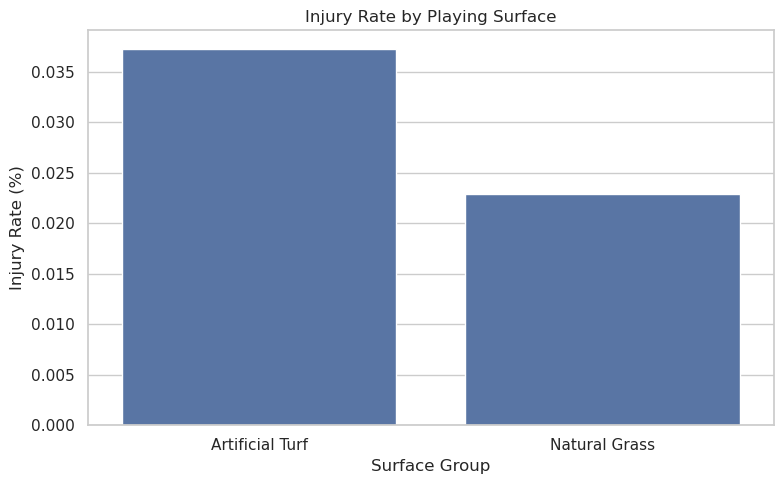

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=summary.reset_index(),
    x="SurfaceGroup",
    y="injury_rate_pct",
    ax=ax
)
ax.set_title("Injury Rate by Playing Surface")
ax.set_xlabel("Surface Group")
ax.set_ylabel("Injury Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Statistical Test

A chi-square test checks whether injury occurrence is independent of surface type.

- **Null hypothesis:** injury occurrence is independent of surface type
- **Alternative hypothesis:** injury occurrence differs by surface type

In [27]:
contingency = pd.crosstab(analysis_df["SurfaceGroup"], analysis_df["Injury"])
contingency

Injury,False,True
SurfaceGroup,,
Artificial Turf,110063,41
Natural Grass,156866,36


In [28]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)
expected_df

Chi-square statistic: 4.1025
p-value: 0.042819
Degrees of freedom: 1


Injury,False,True
SurfaceGroup,,
Artificial Turf,110072.247875,31.752125
Natural Grass,156856.752125,45.247875


## Interpretation Template

Edit this section after running the notebook and seeing the actual results.

**Draft interpretation:**

- The injury rate on artificial turf was **X%**
- The injury rate on natural grass was **Y%**
- The chi-square test produced a p-value of **P**
- Based on this result, we **do / do not** reject the null hypothesis at the 0.05 level

If the p-value is less than 0.05, the difference is statistically significant. If the artificial turf rate is higher, that supports the hypothesis.

## Optional Supporting Analysis

This section is not required for the proposal, but it strengthens the final project by showing how the surface effect may vary across other football contexts such as player position.

,Position,SurfaceGroup,total_records,injury_count,injury_rate
4,DB,Artificial Turf,578,1,0.001730
20,LB,Artificial Turf,983,1,0.001017
16,ILB,Artificial Turf,3391,3,0.000885
23,MLB,Natural Grass,3467,3,0.000865
34,RB,Artificial Turf,4827,4,0.000829
21,LB,Natural Grass,1744,1,0.000573
2,CB,Artificial Turf,12660,7,0.000553
22,MLB,Artificial Turf,2128,1,0.000470
7,DE,Natural Grass,8550,4,0.000468
44,WR,Artificial Turf,19450,9,0.000463


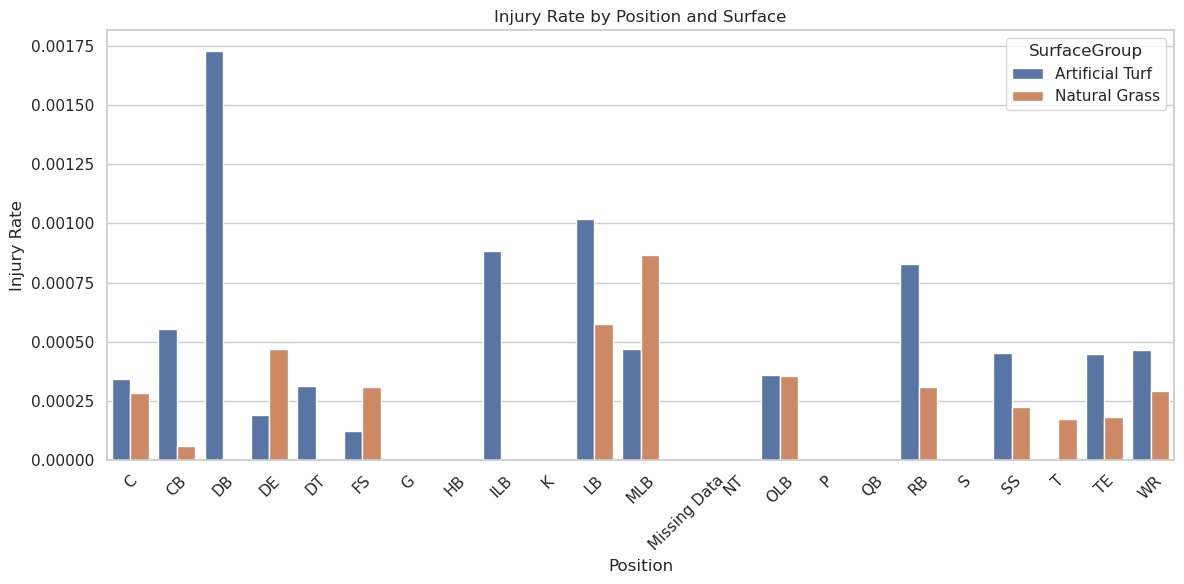

In [29]:
# Optional: injury rate by position and surface if a position column exists
position_candidates = ["Position", "PlayerPosition", "Pos"]
position_col = None
for cand in position_candidates:
    if cand in analysis_df.columns:
        position_col = cand
        break

if position_col is not None:
    position_summary = (
        analysis_df.groupby([position_col, "SurfaceGroup"])
        .agg(
            total_records=("Injury", "size"),
            injury_count=("Injury", "sum"),
            injury_rate=("Injury", "mean")
        )
        .reset_index()
    )

    # Filter to positions with at least a modest number of observations
    eligible_positions = (
        position_summary.groupby(position_col)["total_records"].sum()
        .loc[lambda s: s >= 20]
        .index
    )
    position_summary = position_summary[position_summary[position_col].isin(eligible_positions)]

    display(position_summary.sort_values(["injury_rate", "total_records"], ascending=[False, False]).head(20))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=position_summary,
        x=position_col,
        y="injury_rate",
        hue="SurfaceGroup"
    )
    plt.title("Injury Rate by Position and Surface")
    plt.ylabel("Injury Rate")
    plt.xlabel("Position")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No position column detected. Skipping optional position analysis.")

## Proposal Summary

This project uses a publicly available NFL injury dataset to test whether artificial turf is associated with a higher injury rate than natural grass. The notebook loads the data from Kaggle, cleans and merges the relevant tables, calculates injury rates by surface type, and applies a chi-square test to evaluate whether observed differences are statistically significant. This analysis is appropriate for DATA 720 because it demonstrates data loading, data wrangling, exploratory analysis, visualization, and statistical reasoning using Python.

## Conclusion

This notebook provides a complete starting point for the final project in notebook form. Once run, it should produce:

- a reproducible data-loading workflow
- a merged analysis table
- injury rate comparisons
- at least one primary visualization
- a significance test for the turf-versus-grass question

From there, the same notebook can be extended into the final report and poster presentation.

**AI Use Disclosure**

I used ChatGPT as a support tool in the development of this project. Specifically, I used AI assistance to help structure the project as a one-page proposal and analysis notebook, brainstorm and refine potential project ideas, clarify the research question, and navigate the process of identifying and accessing an appropriate Kaggle dataset. AI was also used to assist with organizing the notebook layout and suggesting ways to present the analysis in a clear and coherent format.

All substantive project decisions, including final topic selection, programming implementation, interpretation of the research question, review of the dataset, execution of the analysis, evaluation of the results, and final editing of the written content, were completed by me.